In [52]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

gen_results = np.load('/Users/isaaclee/Wildfire_Research/wildfire_results_shifted_ln/depth_4_epochs_10000_schedule_VE_sigma_5/generated_mean_std.npz')
gen_samples = np.load('/Users/isaaclee/Wildfire_Research/wildfire_results_shifted_ln/depth_4_epochs_10000_schedule_VE_sigma_5/generated_samples.npz')
real_samples = np.load('/Users/isaaclee/Wildfire_Research/wildfire_results_shifted_ln/depth_4_epochs_10000_schedule_VE_sigma_5/real_samples.npz')
conditional_inputs = np.load('/Users/isaaclee/Wildfire_Research/wildfire_results_shifted_ln/depth_4_epochs_10000_schedule_VE_sigma_5/conditional_inputs.npz')
training_testing_data = np.load('/Users/isaaclee/Wildfire_Research/data/training_testing_data_for_predicting_fire_area_from_ign_time_conditions.npy')
testing_data = training_testing_data[-1200:]
constant = np.load('/Users/isaaclee/Wildfire_Research/data/x_scaling_constant.npz')


print(gen_results.files)
print(gen_samples.files)
print(real_samples.files)
print(conditional_inputs.files)
print(constant.files)

['array1', 'array2']
['arr_0']
['arr_0']
['arr_0']
['constant']


In [53]:
constant = np.load('/Users/isaaclee/Wildfire_Research/data/x_scaling_constant.npz')
constant = constant['constant']

# unnormalize generated samples
gen_samples_raw = gen_samples['arr_0']
gen_samples_unnorm = (np.exp(gen_samples_raw)-1)/constant

# unnormalize generated means
gen_means_raw = gen_results['array1']
gen_means_unnorm = (np.exp(gen_means_raw)-1)/constant

# unnormalize real samples
real_samples_raw = real_samples['arr_0']
real_samples_unnorm = (np.exp(real_samples_raw)-1)/constant

print(gen_samples_unnorm.shape)
print(gen_means_unnorm.shape)
print(real_samples_unnorm.shape)

(1200000, 1)
(1200, 1)
(1200, 1)


In [54]:
gen = gen_samples_unnorm.reshape(1200,1000)
stds = np.std(gen, axis=1)
real = real_samples_unnorm.flatten()
pred = gen_means_unnorm.flatten()

print(stds.shape)
print(real.shape)
print(pred.shape)

within_1_std = np.abs(real - pred) <= stds
proportions = within_1_std.astype(int)
print(np.mean(proportions))

print(np.mean(stds.flatten()))

(1200,)
(1200,)
(1200,)
0.32416666666666666
393.51125563912194


In [55]:
pred = gen_means_unnorm.flatten()
real = real_samples_unnorm.flatten()

print(pred.shape)
print(real.shape)

mae = np.mean(np.abs(real-pred))
print("Mean Absolute Error: " + str(mae))

normalized_mae = mae/np.mean(real)
print("Normalized Mean Absolute Error: " + str(normalized_mae))

mape = np.mean(np.abs(real-pred)/real)
print("Mean Absolute Percent Error: " + str(mape))

(1200,)
(1200,)
Mean Absolute Error: 2207.4641168980324
Normalized Mean Absolute Error: 0.6944733634895298
Mean Absolute Percent Error: 1.3824478782091887


Text(0, 0.5, 'Percent error')

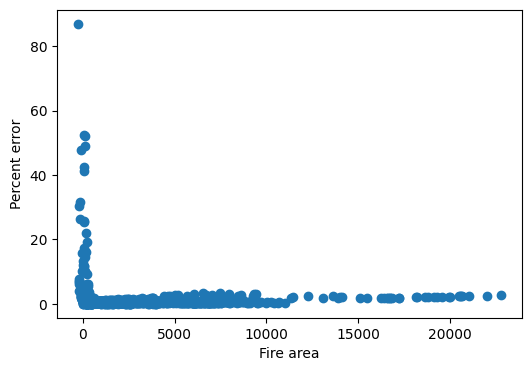

In [56]:
percent_error = np.abs(real-pred)/real
fire_area = pred

plt.figure(figsize=(6,4))
plt.scatter(fire_area, percent_error)
plt.xlabel('Fire area')
plt.ylabel('Percent error')

25409.094848049066
(1200000,)
(1200,)
1.5432147661487163


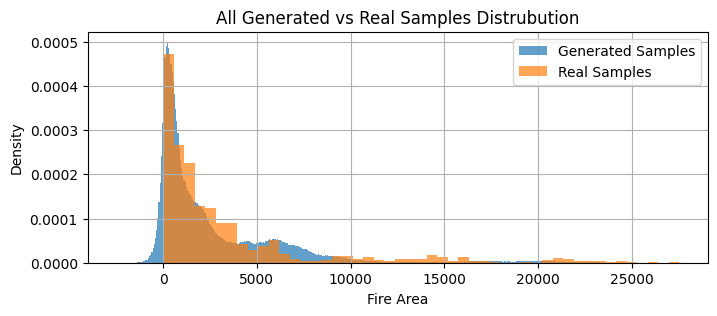

In [57]:
gen = gen_samples_unnorm.flatten()
real = real_samples_unnorm.flatten()

print(max(gen))

print(gen.shape)
print(real.shape)

print(min(real))

plt.figure(figsize=(8,3))
plt.title('All Generated vs Real Samples Distrubution')
plt.hist(gen, bins='auto', alpha=0.7, label='Generated Samples', density=True)
plt.hist(real, bins='auto', alpha=0.7, label='Real Samples', density=True)
# plt.xlim((0,1))
# plt.ylim((0,30))
plt.legend()
plt.xlabel('Fire Area')
plt.ylabel('Density')
plt.grid(True)
plt.show()

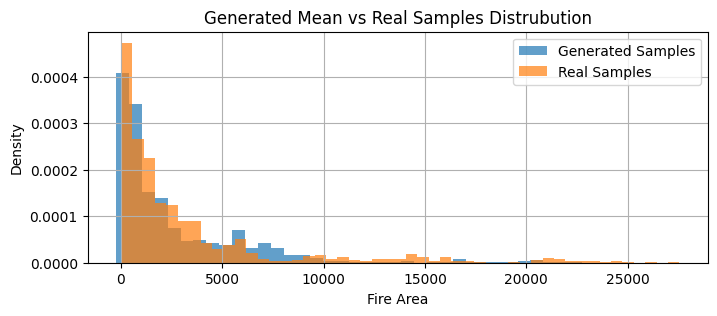

In [58]:
gen_mean = gen_means_unnorm.flatten()
plt.figure(figsize=(8,3))
plt.title('Generated Mean vs Real Samples Distrubution')
plt.hist(gen_mean, bins='auto', alpha=0.7, label='Generated Samples', density=True)
plt.hist(real, bins='auto', alpha=0.7, label='Real Samples', density=True)
plt.legend()
plt.xlabel('Fire Area')
plt.ylabel('Density')
plt.grid(True)
plt.show()